<a href="https://colab.research.google.com/github/P-gadekar123/EMPLOYEE-ATTRITION-PREDICTION-SYSTEM/blob/main/EMPLOYEE_ATTRITION_PREDICTION_SYSTEM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

-------------------------------
# **Upload Dataset to Colab**
------------------------------

In [4]:
from google.colab import files
uploaded = files.upload()

Saving HR-Employee-Attrition.csv to HR-Employee-Attrition (1).csv


In [5]:
import pandas as pd

df = pd.read_csv("HR-Employee-Attrition.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


-----------------------
# **Data Exploration**
-----------------------

In [6]:
df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [7]:
df['Attrition'].value_counts()

,count
Attrition,
No,1233
Yes,237


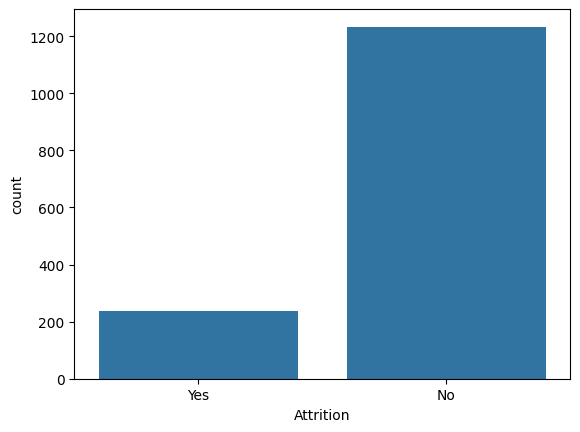

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Attrition', data=df)
plt.show()

-------------------------
# **Data Preprocessing**
-------------------------

In [9]:
df['Attrition'] = df['Attrition'].map({'Yes':1,'No':0})

In [10]:
df = pd.get_dummies(df, drop_first=True)

In [11]:
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

-----------------------
# **Train Test Split**
-----------------------

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

-----------------------
# **Train Model**
-----------------------

In [13]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train, y_train)

RandomForestClassifier()

-----------------------
# **Prediction**
-----------------------

In [14]:
y_pred = model.predict(X_test)

-----------------------
# **Model Evaluate**
-----------------------

In [17]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, classification_report

In [18]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8741496598639455


In [19]:
precision = precision_score(y_test, y_pred)
print("Precision:", precision)

Precision: 0.6666666666666666


In [20]:
recall = recall_score(y_test, y_pred)
print("Recall:", recall)

Recall: 0.10256410256410256


In [21]:
f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

F1 Score: 0.17777777777777778


In [22]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[253   2]
 [ 35   4]]


In [23]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.99      0.93       255
           1       0.67      0.10      0.18        39

    accuracy                           0.87       294
   macro avg       0.77      0.55      0.55       294
weighted avg       0.85      0.87      0.83       294



-----------------------
# **Feature Importance Visualization**
-----------------------

In [24]:
import matplotlib.pyplot as plt
import pandas as pd

importances = model.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

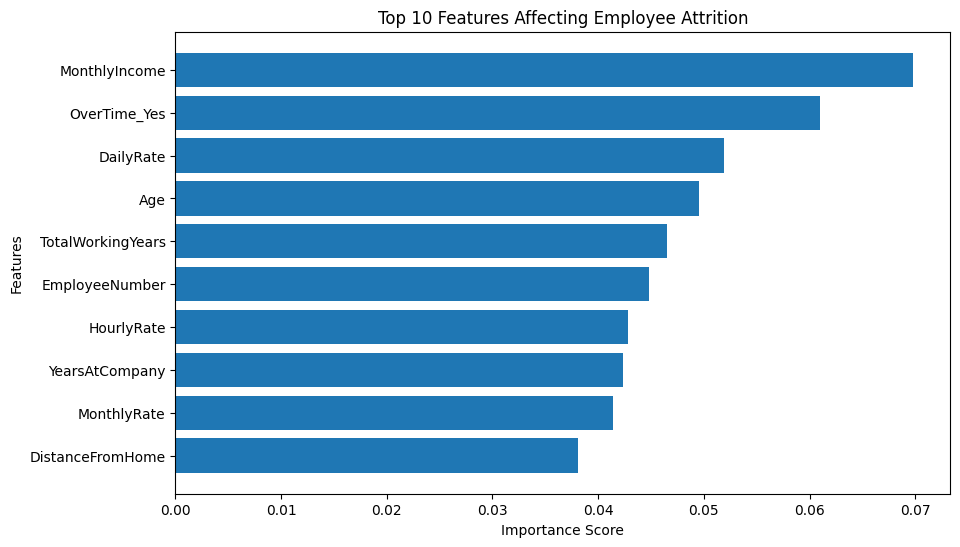

In [25]:
plt.figure(figsize=(10,6))
plt.barh(importance_df['Feature'][:10], importance_df['Importance'][:10])
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 10 Features Affecting Employee Attrition")
plt.gca().invert_yaxis()
plt.show()

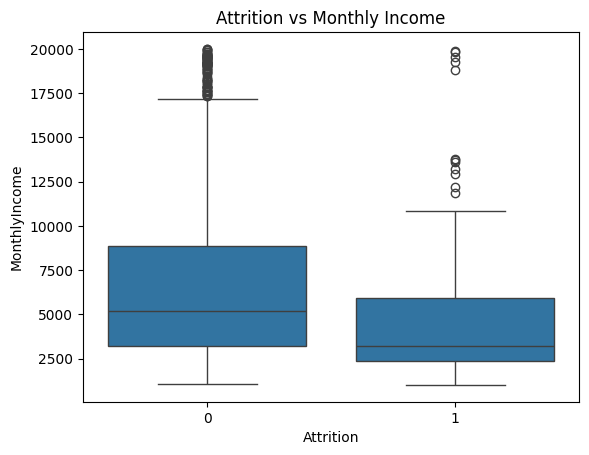

In [26]:
import seaborn as sns

sns.boxplot(x="Attrition", y="MonthlyIncome", data=df)
plt.title("Attrition vs Monthly Income")
plt.show()